# Project-1 | Unsupervised Learning

1. Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from
   numeric columns) – 5 points

In [46]:
import warnings 
warnings.filterwarnings('ignore')

In [47]:
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
# Numerical libraries
import numpy as np 
from sklearn.model_selection import train_test_split
# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
# to handle data in form of rows and columns 
import pandas as pd    
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns

In [48]:
# reading the CSV file into pandas dataframe
mpg_df = pd.read_csv("cars-dataset.csv")  

In [49]:
# Check top few records to get a feel of the data structure
mpg_df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


Let US Look Data and EDA

In [50]:
print(mpg_df.head())

                    car name  cyl   disp   hp    wt   acc  yr   mpg
0  chevrolet chevelle malibu    8  307.0  130  3504  12.0  70  18.0
1          buick skylark 320    8  350.0  165  3693  11.5  70  15.0
2         plymouth satellite    8  318.0  150  3436  11.0  70  18.0
3              amc rebel sst    8  304.0  150  3433  12.0  70  16.0
4                ford torino    8  302.0  140  3449  10.5  70  17.0


In [51]:
print(mpg_df.index)

RangeIndex(start=0, stop=398, step=1)


In [52]:
print(mpg_df.columns)

Index(['car name', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'mpg'], dtype='object')


    1. mpg: Continuous Values   ->  Dependent variable 
    2. cyl: Cylinder is multi-valued discrete ( 3 Cylinders )   -> Indipendent Variable
    3. disp: Displacement Continuous Values   -> Indipendent Variable
    4. hp: Horsepower Continuous Values  -> Indipendent Variable
    5. wt: Weight Continuous Values   -> Indipendent Variable
    6. acc: acceleration Continuous Values  -> Indipendent Variable
    7. yr: Model year Multi-valued discrete  -> Indipendent Variable
    8. car name: String (unique for each instance)  our Targe -> Indipendent Variable

In [53]:
mpg_df.shape

(398, 8)

There are 8 columns and 398 dataset

In [54]:
mpg_df.isnull().any()

car name    False
cyl         False
disp        False
hp          False
wt          False
acc         False
yr          False
mpg         False
dtype: bool

There is no Null Values

In [55]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


hp is continous float value. Hence hp needs to be converted from "object" to  "float64"

In [56]:
temp = pd.DataFrame(mpg_df.hp.str.isdigit()) 
temp[temp['hp'] == False]

,hp
32,False
126,False
330,False
336,False
354,False
374,False


In hp Some of the values are not numaric. Hence We will repalce it first 

In [57]:
mpg_df = mpg_df.replace('?', np.nan)

In [58]:
mpg_df['hp'] = mpg_df['hp'].astype('float64')  # Conver "Object" to "float64"

In [59]:
mpg_df = mpg_df.fillna(mpg_df.mean())


In [60]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [61]:
mpg_df.describe()

,cyl,disp,hp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,46.600000


Let us Check one by one all attributes

In [62]:
mpg_df.mpg.describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

So the minimum value is 9 and maximum is 46, but on average it is 23.44 with a variation of 7.8

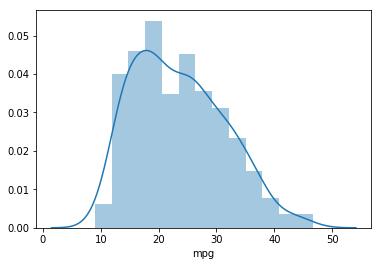

In [63]:
sns.distplot(mpg_df['mpg'])

In [64]:
print("Skewness: %f" % mpg_df['mpg'].skew())
print("Kurtosis: %f" % mpg_df['mpg'].kurt())

Skewness: 0.457066
Kurtosis: -0.510781


It is normally distributed. 

In [65]:
#hp go "Nan" Values. Hence Checked data. Looks mean the dat is ok. 
mpg_df= mpg_df.fillna(mpg_df.mean())

Skewness: 0.719645
Kurtosis: -0.746597


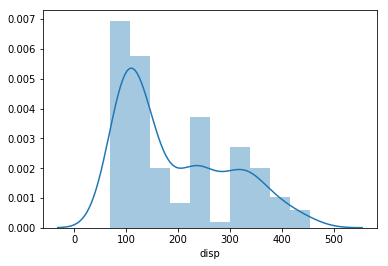

In [66]:
sns.distplot(mpg_df['disp'])
print("Skewness: %f" % mpg_df['disp'].skew())
print("Kurtosis: %f" % mpg_df['disp'].kurt())

Skewness: 1.095552
Kurtosis: 0.753509


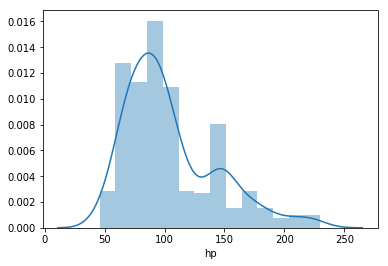

In [67]:
sns.distplot(mpg_df['hp'])
print("Skewness: %f" % mpg_df['hp'].skew())
print("Kurtosis: %f" % mpg_df['hp'].kurt())

Skewness: 0.531063
Kurtosis: -0.785529


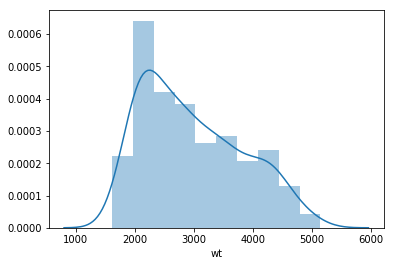

In [68]:
sns.distplot(mpg_df['wt'])
print("Skewness: %f" % mpg_df['wt'].skew())
print("Kurtosis: %f" % mpg_df['wt'].kurt())

Skewness: 0.278777
Kurtosis: 0.419497


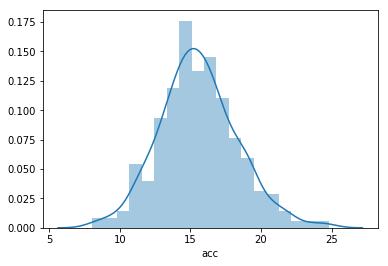

In [69]:
sns.distplot(mpg_df['acc'])
print("Skewness: %f" % mpg_df['acc'].skew())
print("Kurtosis: %f" % mpg_df['acc'].kurt())

Skewness: 0.011535
Kurtosis: -1.181232


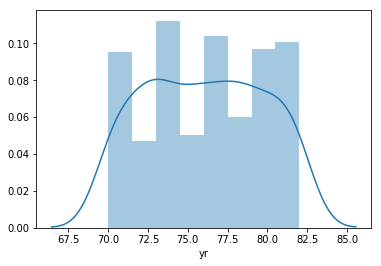

In [70]:
sns.distplot(mpg_df['yr'])
print("Skewness: %f" % mpg_df['yr'].skew())
print("Kurtosis: %f" % mpg_df['yr'].kurt())

Skewness: 0.526922
Kurtosis: -1.376662


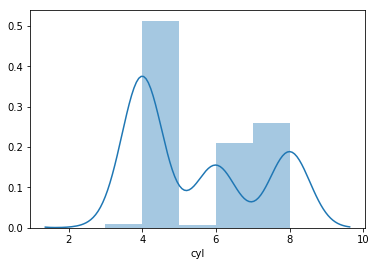

In [71]:
sns.distplot(mpg_df['cyl'])
print("Skewness: %f" % mpg_df['cyl'].skew())
print("Kurtosis: %f" % mpg_df['cyl'].kurt())

Lets scale the data between [0,1]

In [72]:
def scale(a):
    b = (a-a.min())/(a.max()-a.min())
    return b

In [73]:
mpg_scale = mpg_df.copy()

In [74]:
mpg_scale ['disp'] = scale(mpg_scale['disp'])
mpg_scale['hp'] = scale(mpg_scale['hp'])
mpg_scale ['acc'] = scale(mpg_scale['acc'])
mpg_scale ['wt'] = scale(mpg_scale['wt'])
mpg_scale['mpg'] = scale(mpg_scale['mpg'])

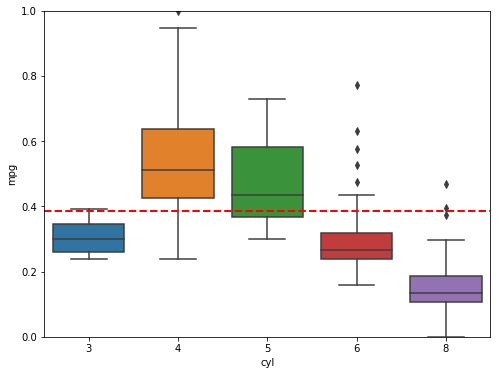

In [75]:
var = 'cyl'
data_plt = pd.concat([mpg_scale['mpg'], mpg_scale[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="mpg", data=data_plt)
fig.axis(ymin=0, ymax=1)
plt.axhline(mpg_scale.mpg.mean(),color='r',linestyle='dashed',linewidth=2)

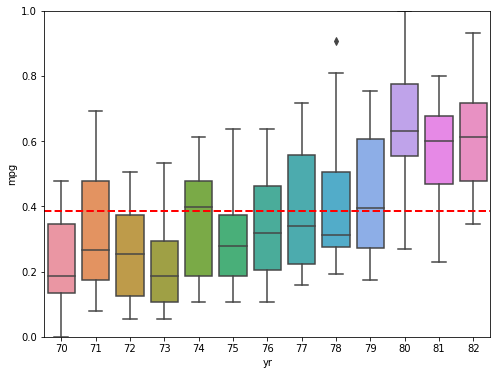

In [76]:
var = 'yr'
data_plt = pd.concat([mpg_scale['mpg'], mpg_scale[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="mpg", data=data_plt)
fig.axis(ymin=0, ymax=1)
plt.axhline(mpg_scale.mpg.mean(),color='r',linestyle='dashed',linewidth=2)

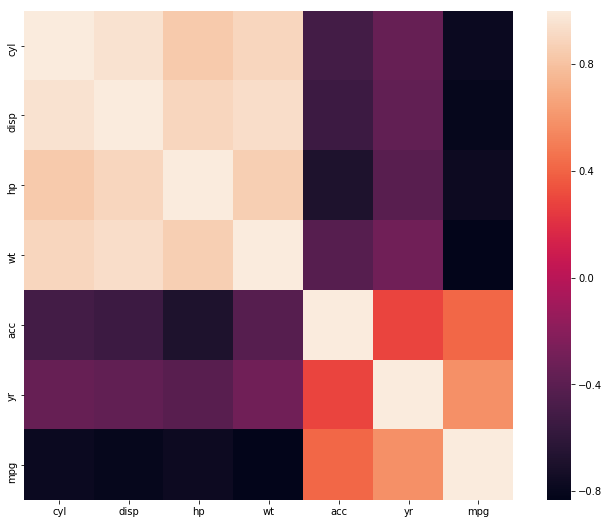

In [77]:
corrmat = mpg_df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, square=True);

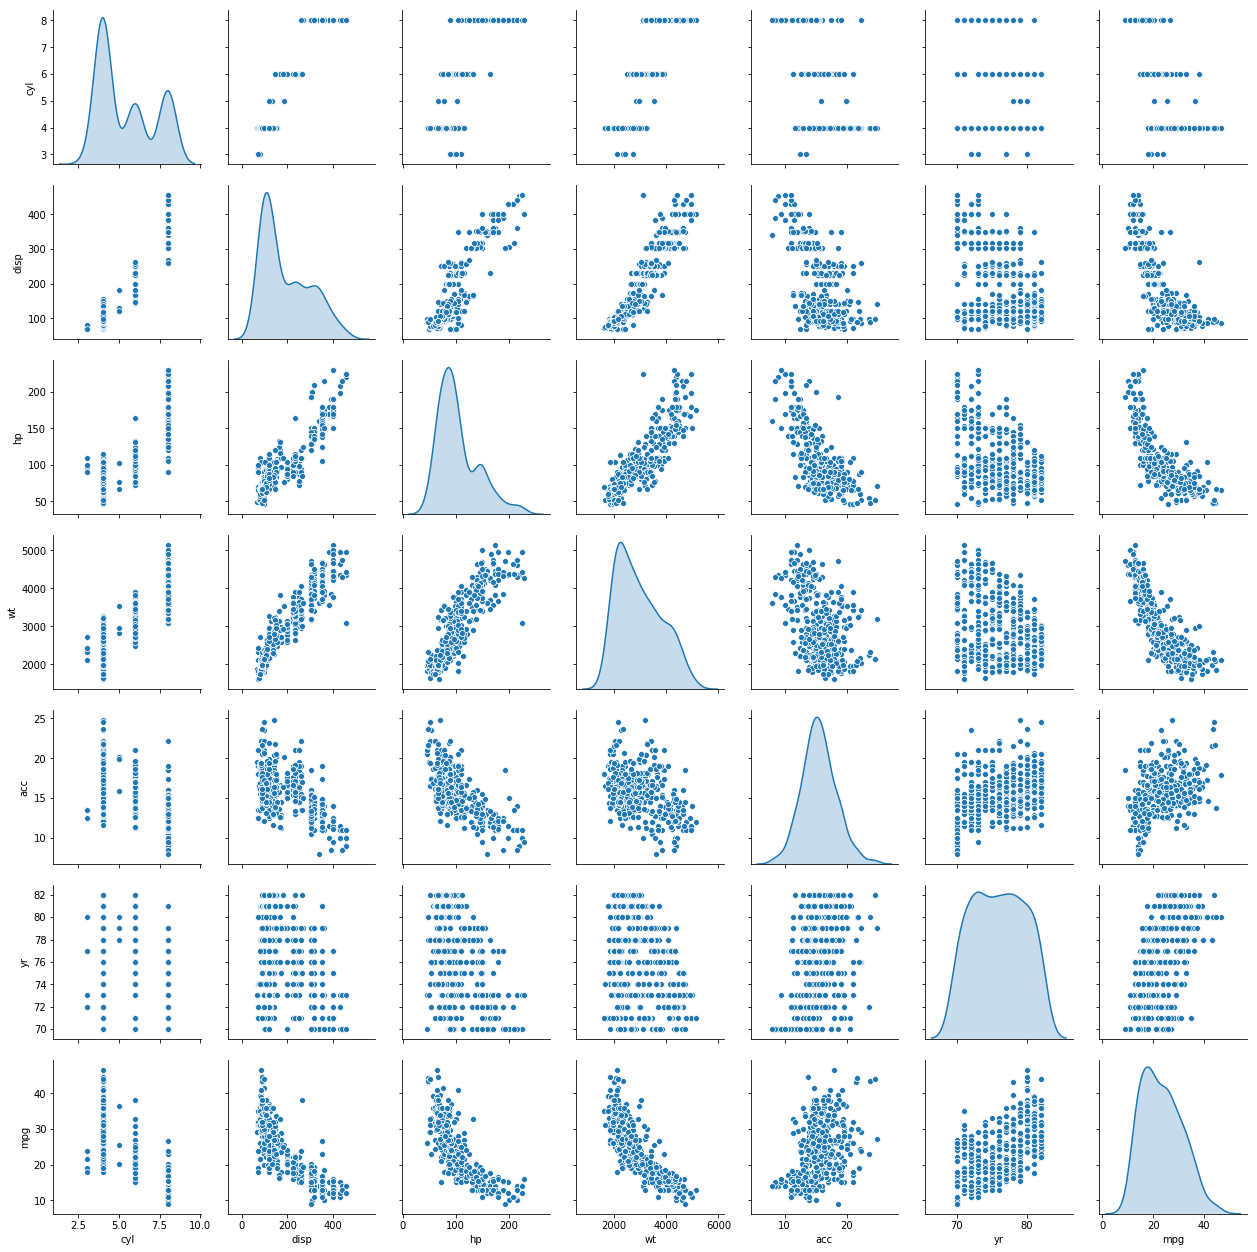

In [78]:
#scatterplot
sns.pairplot(mpg_df, diag_kind='kde')   # to plot density curve instead of histogram

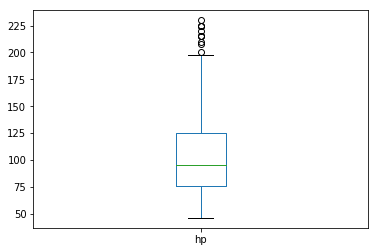

In [81]:
mpg_df['hp'].plot(kind='box')

In [82]:
Q3 = mpg_df["hp"].quantile(0.75)
Q1 = mpg_df["hp"].quantile(0.25)
diff = Q3-Q1
Above_outliers = Q3+diff
Below_outliers = Q1-diff
print("Above outliers : {}".format(Above_outliers))
print("Below outliers : {}".format(Below_outliers))

Above outliers : 174.0
Below outliers : 27.0


In [83]:
mean1 = mpg_df["hp"].loc[mpg_df["hp"]<=Above_outliers].max()
mpg_df["hp"] = mpg_df["hp"].mask(mpg_df["hp"]>Above_outliers,mean1)

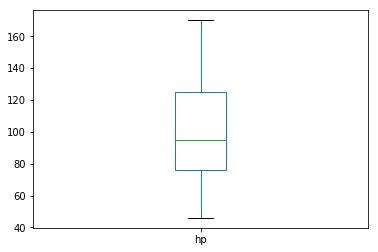

In [84]:
mpg_df['hp'].plot(kind='box')

In [87]:
mpg_df = mpg_df.drop(["car name"],axis=1)

In [88]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
cyl     398 non-null int64
disp    398 non-null float64
hp      398 non-null float64
wt      398 non-null int64
acc     398 non-null float64
yr      398 non-null int64
mpg     398 non-null float64
dtypes: float64(4), int64(3)
memory usage: 21.8 KB


In [89]:
# PCA
# Step 1 - Create covariance matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
sc = StandardScaler()
mpg_scale =  sc.fit_transform(mpg_df)
mpg_scaled = pd.DataFrame(mpg_scale,columns=['cyl','disp','hp','wt','acc','yr','mpg'])


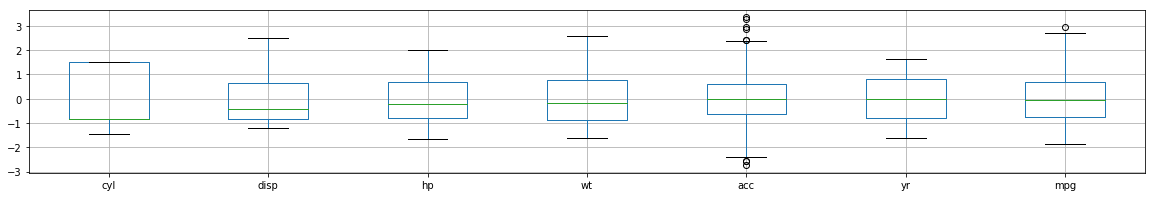

In [91]:
mpg_scaled.boxplot(figsize=(20,3))

In [92]:
X= mpg_scaled.drop(["mpg"],axis=1)
y=mpg_scaled["mpg"]

In [93]:
cov_matrix = np.cov(X.T)

In [94]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[ 4.56136792e-01  1.71720650e-01 -1.69802328e-01 -6.55181006e-01
  -3.93518236e-01  3.86651861e-01]
 [ 4.67579134e-01  1.49900049e-01 -1.37395487e-01 -2.58361755e-01
   7.31395997e-01 -3.71929170e-01]
 [ 4.65767256e-01  3.85742486e-02  1.16414599e-01  5.43254249e-01
   2.36471312e-01  6.45737308e-01]
 [ 4.46708905e-01  2.46028552e-01 -2.73967794e-01  4.45808923e-01
  -4.77920434e-01 -4.87554322e-01]
 [-3.23323885e-01  2.04792499e-01 -8.73484958e-01  1.00579709e-01
   1.56454801e-01  2.36540362e-01]
 [-2.28654027e-01  9.18740445e-01  3.17337306e-01  1.33888754e-06
   3.73974076e-02  3.91382057e-02]]

 Eigen Values 
%s [4.28134066 0.84194143 0.67396912 0.12412783 0.0342781  0.05945621]


In [95]:
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]
# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()
eig_pairs.reverse()
print(eig_pairs)
# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(4.281340659775408, array([ 0.45613679,  0.46757913,  0.46576726,  0.4467089 , -0.32332388,
       -0.22865403])), (0.8419414278986806, array([0.17172065, 0.14990005, 0.03857425, 0.24602855, 0.2047925 ,
       0.91874044])), (0.6739691201607436, array([-0.16980233, -0.13739549,  0.1164146 , -0.27396779, -0.87348496,
        0.31733731])), (0.12412783463634311, array([-6.55181006e-01, -2.58361755e-01,  5.43254249e-01,  4.45808923e-01,
        1.00579709e-01,  1.33888754e-06])), (0.05945621123384906, array([ 0.38665186, -0.37192917,  0.64573731, -0.48755432,  0.23654036,
        0.03913821])), (0.03427809642092741, array([-0.39351824,  0.731396  ,  0.23647131, -0.47792043,  0.1564548 ,
        0.03739741]))]
Eigenvalues in descending order: 
[4.281340659775408, 0.8419414278986806, 0.6739691201607436, 0.12412783463634311, 0.05945621123384906, 0.03427809642092741]


In [100]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  
cum_var_exp = np.cumsum(var_explained)
print(var_explained)
print(cum_var_exp)

[0.7117639204065473, 0.13997099952921938, 0.11204595506859923, 0.02063599260914077, 0.009884470628072886, 0.005698661758420506]
[0.71176392 0.85173492 0.96378088 0.98441687 0.99430134 1.        ]


In [102]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:4])   # Reducing from 8 to 4 dimension space

X_std_4D = np.dot(X,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

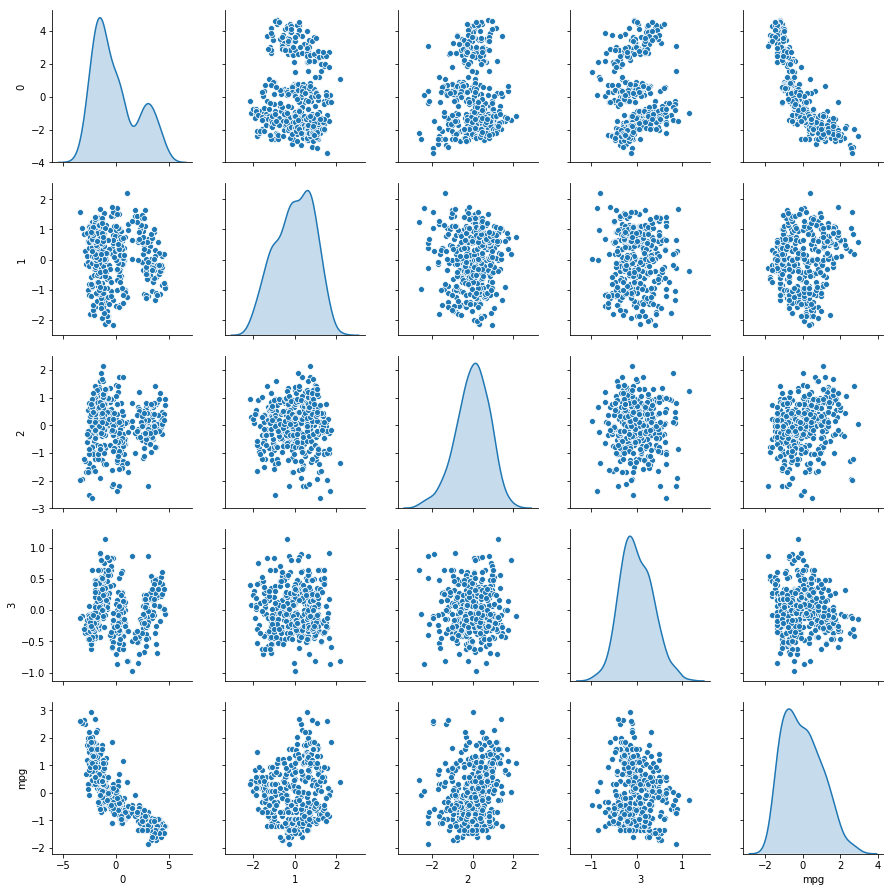

In [103]:
#Let us check it visually
Proj_data_mpg_df = Proj_data_df.join(y)

sns.pairplot(Proj_data_mpg_df, diag_kind='kde') 

In [104]:

from sklearn.cluster import KMeans
# Let us check optimal number of clusters-
cluster_range = range( 1, 10)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
cluster_sil_scores = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(Proj_data_mpg_df)
  labels = clusters.labels_                     # capture the cluster lables
  centroids = clusters.cluster_centers_         # capture the centroids
  cluster_errors.append( clusters.inertia_ )    # capture the intertia
# combine the cluster_range and cluster_errors into a dataframe by combining them
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors} )
clusters_df[0:15]



,num_clusters,cluster_errors
0,1,2748.787480
1,2,1244.598235
2,3,893.275581
3,4,687.697817
4,5,616.065488
5,6,557.035560
6,7,504.762732
7,8,456.893028
8,9,427.465639


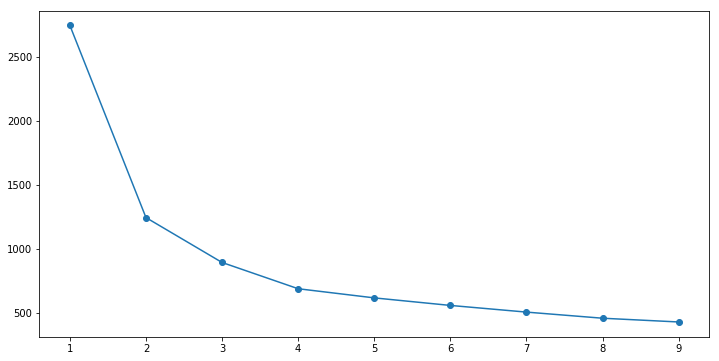

In [105]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [37]:
#Based on the above elbow method, 4 Clusters recommended. 

In [106]:
cluster = KMeans( n_clusters = 4, random_state = 2354 )
cluster.fit(Proj_data_mpg_df)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=2354, tol=0.0001, verbose=0)

In [107]:
centroids = cluster.cluster_centers_
centroids

array([[-1.30452971, -1.00642587, -0.0754751 ,  0.15265877,  0.19246689],
       [ 3.22699352,  0.0475802 ,  0.0610665 , -0.01967841, -1.15871315],
       [-1.85794007,  0.60740091,  0.35848059,  0.00963876,  1.18462537],
       [ 0.3759535 ,  0.30540184, -0.43069016, -0.1609512 , -0.47812895]])

In [109]:
centroid_df = pd.DataFrame(centroids, columns = list(Proj_data_mpg_df) )
centroid_df

,0,1,2,3,mpg
0,-1.304530,-1.006426,-0.075475,0.152659,0.192467
1,3.226994,0.047580,0.061067,-0.019678,-1.158713
2,-1.857940,0.607401,0.358481,0.009639,1.184625
3,0.375953,0.305402,-0.430690,-0.160951,-0.478129


In [114]:
prediction=cluster.predict(Proj_data_mpg_df)
Proj_data_mpg_df["GROUP"] = prediction     # Creating a new column "GROUP" which will hold the cluster id of each record

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002413BD1A438>,
      dtype=object)

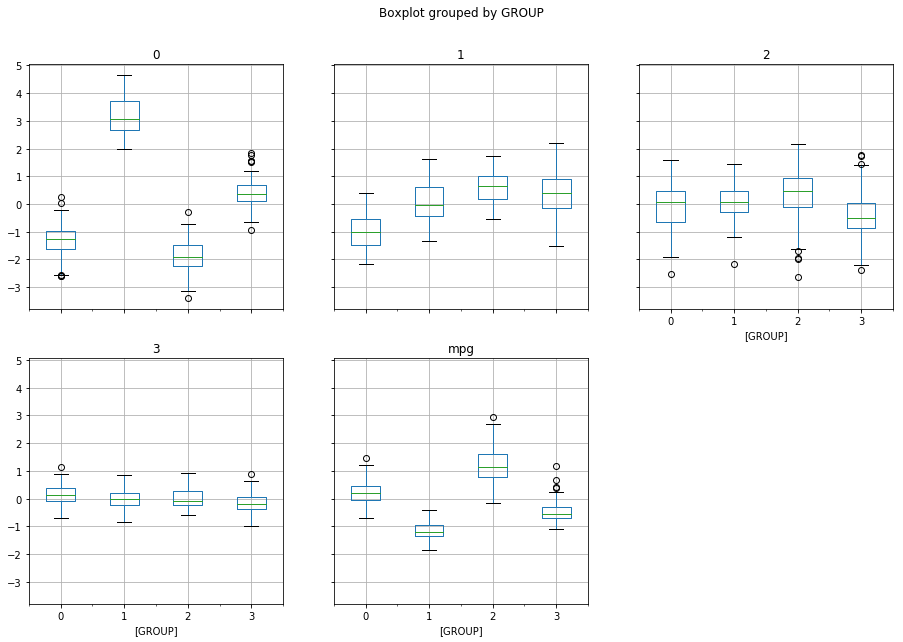

In [115]:
import matplotlib.pylab as plt

Proj_data_mpg_df.boxplot(by = 'GROUP',  layout=(2,3), figsize=(15, 10))

In [116]:
Proj_data_mpg_df['lables'] = pd.DataFrame(cluster.labels_ , columns = list(['labels']))

In [117]:
Proj_data_mpg_df['lables'].value_counts()

2    113
0    100
1     95
3     90
Name: lables, dtype: int64

In [119]:
X = Proj_data_mpg_df.drop(['GROUP'],axis=1)

In [120]:
XC1 = X.loc[X['lables'] ==0]

In [121]:
XC1 = XC1.drop(['lables'],axis=1)

In [122]:
XC1.shape

(100, 5)

In [123]:
XC2 = X.loc[X['lables'] ==1]
XC2 = XC2.drop(['lables'],axis=1)

In [124]:
XC2.shape

(95, 5)

In [125]:
XC3 = X.loc[X['lables'] ==2]
XC3 = XC3.drop(['lables'],axis=1)

In [126]:
XC3.shape

(113, 5)

In [127]:
XC4 = X.loc[X['lables'] ==3]
XC4 = XC4.drop(['lables'],axis=1)

In [128]:
XC4.shape

(90, 5)

# Hierarchical Clustering 

In [129]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist

In [131]:
Z = linkage(Proj_data_mpg_df, 'average')
c, coph_dists = cophenet(Z , pdist(Proj_data_mpg_df))

c

0.8658427932526142

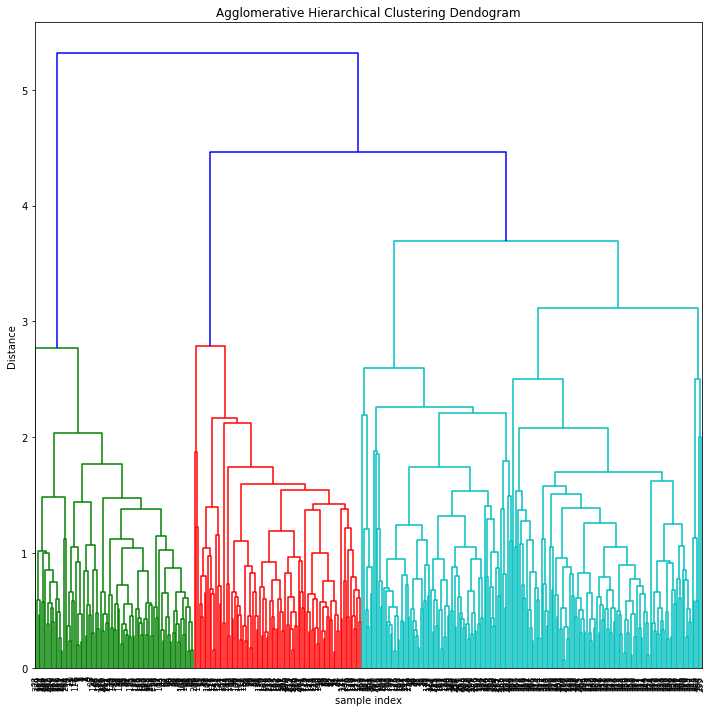

In [134]:
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold =4, leaf_font_size=8. )
plt.tight_layout()

In [111]:
## #Based on the above dendrogram method, 4 Clusters recommended. 

In [135]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')  
cluster.fit_predict(Proj_data_mpg_df) 

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1,
       1, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 3, 2, 2,
       2, 2, 2, 3, 2, 1, 1, 2, 2, 2, 2, 1, 2, 3, 1, 3, 3, 3, 3, 2, 2, 2,
       2, 3, 3, 3, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 1, 2, 2, 3, 2, 2, 2, 2, 3, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 3, 3, 3, 3, 0, 2, 2,
       0, 3, 3, 3, 3, 2, 0, 2, 2, 2, 1, 2, 3, 3, 1, 1, 1, 1, 0, 0, 0, 2,
       0, 1, 3, 1, 1, 3, 3, 3, 3, 1, 1, 1, 1, 0, 2, 2, 2, 0, 0, 0, 0, 3,
       2, 2, 0, 0, 0, 0, 0, 3, 1, 1, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 1, 3,
       1, 1, 0, 0, 0, 0, 2, 2, 2, 2, 3, 3, 2, 3, 0, 0, 3, 3, 0, 3, 3, 3,
       1, 1, 1, 1, 1, 3, 1, 0, 0, 0, 0, 3, 3, 0, 3,

In [136]:
from scipy.cluster.hierarchy import ward, fcluster
fcluster(Z, t=0.9, criterion='distance')

array([ 9,  9,  9,  9,  9,  7,  7,  7,  7,  6,  6,  6,  6,  6, 37, 52, 52,
       27, 37, 22, 30, 37, 30, 38, 27, 15, 15, 15, 18, 37, 37, 37, 30, 53,
       52, 52, 52, 52, 16, 16, 13, 13, 16, 16, 16, 53, 29, 52, 52, 37, 37,
       22, 37, 22, 26, 22, 22, 37, 30, 19, 29, 30, 16, 16, 13, 13, 10, 16,
       16, 16, 16, 39, 13, 13, 12, 13, 41, 29, 29, 30, 30, 30, 37, 37, 30,
       16, 10, 13, 13, 13, 16, 16, 16, 13, 16, 16, 10, 50, 55, 50, 50, 50,
       24, 17, 16, 16, 16, 50, 29, 29, 30, 39, 29, 53, 36, 13,  8, 23, 36,
       42, 41, 10, 42, 53, 10, 50, 50, 50, 55, 23, 31, 23, 31, 55, 55, 54,
       13, 14, 14, 12, 12, 32, 36, 36, 25, 23, 36, 36, 36, 42, 36, 25, 50,
       54, 46, 46, 11, 14, 14, 14, 47, 55, 55, 55, 51, 64,  4, 32, 31, 50,
       31, 42, 32, 31, 51, 28, 58, 42, 31, 42, 42, 25, 32, 32, 33, 32, 32,
       14, 14,  1, 14, 51, 51, 58, 58, 93, 20, 28, 80, 57, 46, 54, 58, 28,
       80, 32, 33, 34, 14, 21, 51, 54, 11, 14,  1, 14, 79, 81, 80, 33, 80,
        3, 67,  3,  1, 54

In [137]:
from sklearn.cluster import AgglomerativeClustering 
data = Proj_data_df.iloc[:, 1:3].values

In [138]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')  
cluster.fit_predict(data) 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 3, 3, 3, 1, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 0, 3, 3, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 1, 3, 3, 3, 0, 1, 3, 3, 3, 0, 3, 0,
       0, 0, 3, 0, 0, 3, 2, 0, 0, 0, 0, 2, 0, 0, 2, 3, 3, 3, 3, 3, 0, 0,
       3, 1, 1, 3, 3, 1, 3, 1, 1, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 3,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 3, 3, 2, 3, 3, 3, 3, 0, 3, 3, 3, 0,
       3, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 3, 1, 1, 1, 1, 0,
       3, 1, 1, 1, 1, 0, 3, 3, 2, 3, 2, 1, 3, 1, 2, 2, 1, 2, 3, 2, 3, 3,
       3, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 3, 3, 3, 3, 3, 3, 2, 3,
       2, 2, 1, 2, 3, 3, 3, 1, 2, 2, 1, 1, 2, 3, 1, 1, 2, 1, 1, 2, 2, 2,
       2, 1, 3, 2, 2, 2, 2, 3, 1, 2, 3, 2, 3, 2, 2, 3, 2, 1, 2, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1,

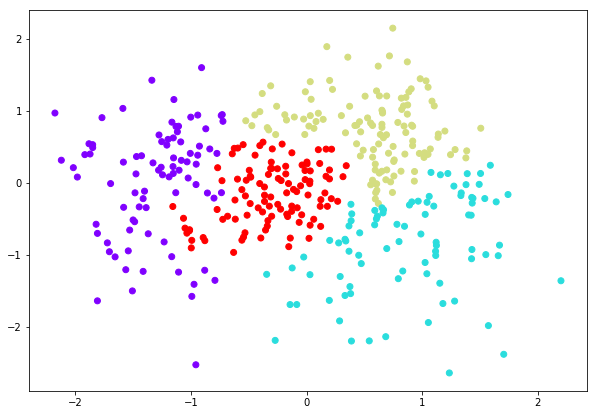

In [139]:
plt.figure(figsize=(10, 7))  
plt.scatter(data[:,0], data[:,1], c=cluster.labels_, cmap='rainbow')  

In [140]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

# Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [141]:
#Data set 1
XC1.head()

,0,1,2,3,mpg
14,-0.734321,-1.983039,0.082751,0.301519,0.062185
17,0.051385,-1.530188,-0.653232,-0.696838,-0.322127
18,-0.971932,-2.121648,0.316665,0.082666,0.446497
19,-2.412003,-1.809353,-1.635585,-0.530106,0.318393
20,-0.993281,-1.723349,-0.830937,0.429552,0.190289


In [143]:
X = XC1.drop(["mpg"], axis=1)
y=XC1["mpg"]

In [144]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [145]:
model =  LinearRegression()

In [146]:
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [147]:
y_predicted = model.predict(X_test)

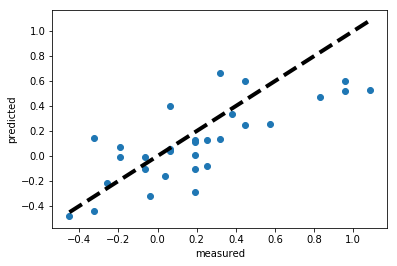

In [149]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_predicted)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('measured')
ax.set_ylabel('predicted')
plt.show()

In [157]:
# model evaluation
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
# printing values
print('Slope:',model.coef_)
print('Intercept:',model.intercept_)
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [-0.40721283 -0.09155226  0.21659413 -0.5018781 ]
Intercept: -0.36620749064876323
Root mean squared error:  0.0711323173501237
R2 score:  0.5190627218638177


In [72]:
#Data set 2

In [158]:
X = XC2.drop(["mpg"], axis=1)
y=XC2["mpg"]

In [159]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [160]:
model =  LinearRegression()

In [161]:
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [162]:
y_predicted = model.predict(X_test)

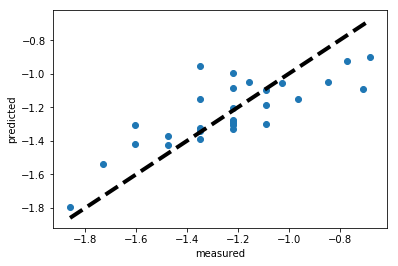

In [163]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_predicted)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('measured')
ax.set_ylabel('predicted')
plt.show()

In [164]:
# model evaluation
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
# printing values
print('Slope:',model.coef_)
print('Intercept:',model.intercept_)
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [-0.12169948  0.09346029  0.22705381 -0.13351203]
Intercept: -0.7863629981661266
Root mean squared error:  0.028736180379443622
R2 score:  0.6255121562267321


In [ ]:
#Data Set 3

In [165]:
X = XC3.drop(["mpg"], axis=1)
y=XC3["mpg"]

In [166]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [167]:
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [168]:
y_predicted = model.predict(X_test)

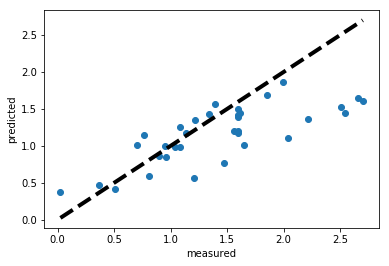

In [169]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_predicted)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('measured')
ax.set_ylabel('predicted')
plt.show()

In [170]:
# model evaluation
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
# printing values
print('Slope:',model.coef_)
print('Intercept:',model.intercept_)
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [-0.40066696  0.2447397   0.16525576 -0.88703458]
Intercept: 0.16239258507176368
Root mean squared error:  0.24847069936384536
R2 score:  0.39241476187990953


In [ ]:
#Data set 4

In [171]:
X = XC4.drop(["mpg"], axis=1)
y=XC4["mpg"]

In [172]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [173]:
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [174]:
y_predicted = model.predict(X_test)

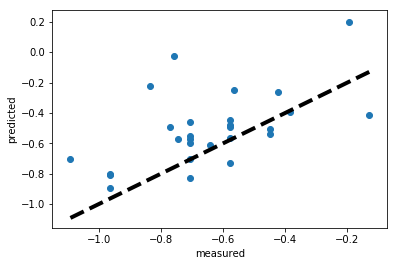

In [175]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_predicted)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('measured')
ax.set_ylabel('predicted')
plt.show()

In [176]:
# model evaluation
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
# printing values
print('Slope:',model.coef_)
print('Intercept:',model.intercept_)
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [-0.17740062  0.18492302  0.27804513 -0.32329496]
Intercept: -0.35848179225736343
Root mean squared error:  0.06598370874628913
R2 score:  -0.3843580843991996


# Just tried with overall data

In [178]:
X=Proj_data_mpg_df.drop(['GROUP','lables','mpg'],axis=1)

In [179]:
y=Proj_data_mpg_df["mpg"]

In [180]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [181]:
model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [182]:
y_predicted = model.predict(X_test)

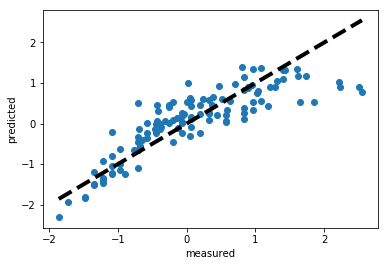

In [183]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_predicted)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('measured')
ax.set_ylabel('predicted')
plt.show()

In [184]:
# model evaluation
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
# printing values
print('Slope:',model.coef_)
print('Intercept:',model.intercept_)
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [-0.40120467  0.16155968  0.34825592 -0.31766956]
Intercept: -0.0036656775931218494
Root mean squared error:  0.24372128957814762
R2 score:  0.7281459643912103


In [189]:
print("Model Score",model.score(X_test, y_test))

Model Score 0.7281459643912103


In [190]:
from sklearn.ensemble import GradientBoostingRegressor
gb_regressor = GradientBoostingRegressor(n_estimators=4000)
gb_regressor.fit(X_train,y_train)

GradientBoostingRegressor(alpha=0.9, criterion='friedman_mse', init=None,
             learning_rate=0.1, loss='ls', max_depth=3, max_features=None,
             max_leaf_nodes=None, min_impurity_decrease=0.0,
             min_impurity_split=None, min_samples_leaf=1,
             min_samples_split=2, min_weight_fraction_leaf=0.0,
             n_estimators=4000, n_iter_no_change=None, presort='auto',
             random_state=None, subsample=1.0, tol=0.0001,
             validation_fraction=0.1, verbose=0, warm_start=False)

In [192]:
y_predicted_gbr_t = gb_regressor.predict(X_test)

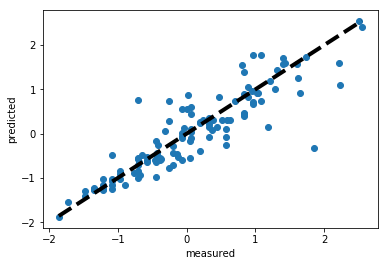

In [193]:
fig, ax = plt.subplots()
ax.scatter(y_test,y_predicted_gbr_t)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('measured')
ax.set_ylabel('predicted')
plt.show()

In [197]:
# model evaluation
rmse = mean_squared_error(y_test,y_predicted_gbr_t)
r2 = r2_score(y_test,y_predicted_gbr_t)
# printing values
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Root mean squared error:  0.18368032371536203
R2 score:  0.7951174583460467
